In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for folder in os.listdir('./archive'):
    if 'IQ-OTHNCCD' in folder or 'lung' in folder.lower():
        dataset_path = os.path.join('./archive', folder)
        break


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
%config Completer.use_jedi = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import seaborn as sns
import cv2
import random
import os
import imageio
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from collections import Counter
import platform

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold
from imblearn.over_sampling import SMOTE

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras.applications import resnet

# CUDA / GPU setup (TensorFlow akan otomatis pakai GPU bila tersedia)
print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'CUDA GPU terdeteksi: {[gpu.name for gpu in gpus]}')
    except RuntimeError as e:
        print(f'Peringatan konfigurasi GPU: {e}')
else:
    print('GPU CUDA tidak terdeteksi. Training akan berjalan di CPU.')
    tf_major, tf_minor = map(int, tf.__version__.split('.')[:2])
    if platform.system() == 'Windows' and (tf_major > 2 or (tf_major == 2 and tf_minor >= 11)):
        print('Catatan: TensorFlow >= 2.11 di Windows native tidak mendukung CUDA GPU.')
        print('Solusi: pakai WSL2 + CUDA, atau gunakan TensorFlow 2.10 + CUDA 11.2 + cuDNN 8.1.')

TensorFlow version: 2.10.0
CUDA GPU terdeteksi: ['/physical_device:GPU:0']


In [3]:
directory = dataset_path

categories = ['Bengin cases', 'Malignant cases', 'Normal cases']

Bengin cases - Bengin case (1).jpg
Malignant cases - Malignant case (1).jpg
Normal cases - Normal case (1).jpg


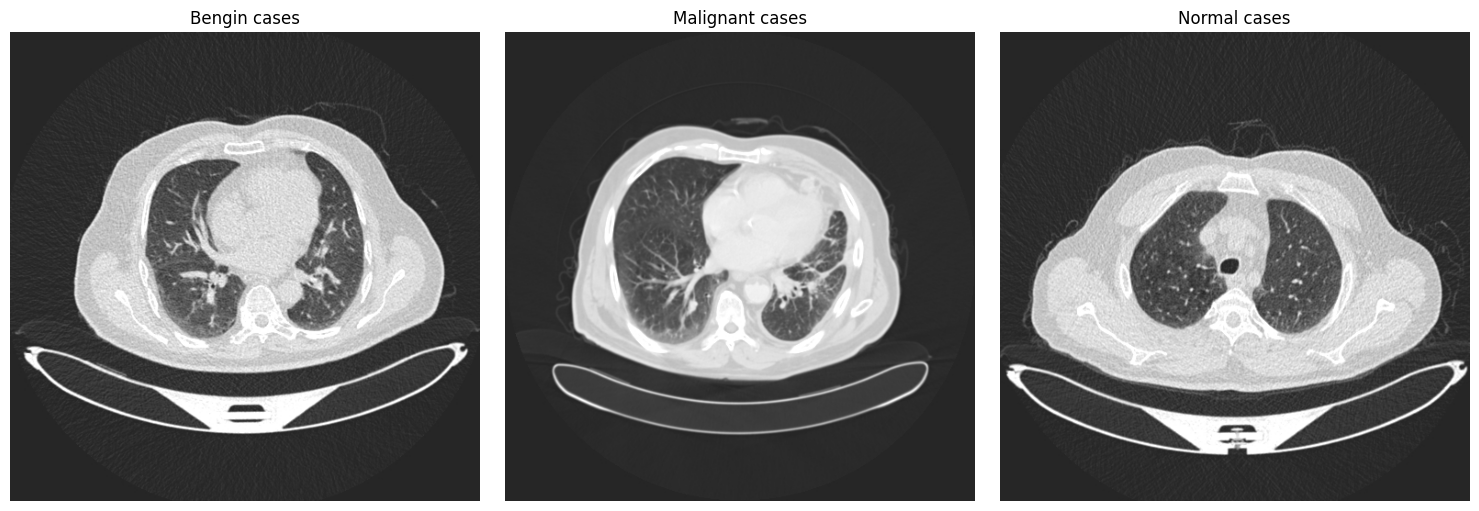

In [4]:
fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))

for i, category in enumerate(categories):
    path = os.path.join(directory, category)
    # Loop files but break after the first one to show just one sample
    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), category)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"Folder tidak ditemukan: {path}")
            axes[i].axis('off')
            continue

    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        print(category, '-', file)

        # Baca image asli (BGR) dan konversi ke RGB
        img = cv2.imread(filepath)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Tampilkan di subplot yang sesuai
        axes[i].imshow(img)
        axes[i].set_title(f'{category}')
        axes[i].axis('off')
        break

plt.tight_layout()
plt.show()

In [5]:
size_data = {}
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)
    temp_dict = {}
    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), i)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"Folder tidak ditemukan: {path}")
            continue

    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        height, width, channels = imageio.imread(filepath).shape
        if str(height) + ' x ' + str(width) in temp_dict:
            temp_dict[str(height) + ' x ' + str(width)] += 1
        else:
            temp_dict[str(height) + ' x ' + str(width)] = 1

    size_data[i] = temp_dict

size_data

C:\Users\User\AppData\Local\Temp\ipykernel_26492\4177532465.py:16: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  height, width, channels = imageio.imread(filepath).shape


{'Bengin cases': {'512 x 512': 120},
 'Malignant cases': {'512 x 512': 501,
  '404 x 511': 1,
  '512 x 801': 28,
  '512 x 623': 31},
 'Normal cases': {'512 x 512': 415, '331 x 506': 1}}

In [6]:
import os, cv2, random
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Inisialisasi
data = []
img_size = 224 # WAJIB 224 untuk MobileNetV2

# Pastikan variabel 'categories' dan 'directory' sudah didefinisikan sebelumnya
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)

    if not os.path.isdir(path):
        nested_path = os.path.join(directory, os.path.basename(directory), i)
        if os.path.isdir(nested_path):
            path = nested_path
        else:
            print(f"Folder tidak ditemukan: {path}")
            continue

    for file in os.listdir(path):
        if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
            continue
        filepath = os.path.join(path, file)
        
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        # Konversi ke RGB karena MobileNetV2 mengharapkan 3 channel
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        data.append([img, class_num])

# Shuffle untuk memastikan variasi data saat splitting
random.shuffle(data)

# Memisahkan fitur (X) dan label (y)
X, y = zip(*data)
X = np.array(X, dtype=np.float32)
y = np.array(y)

print('--- Data Loaded ---')
print('Total X shape:', X.shape)
print('Label distribution:', Counter(y))

--- Data Loaded ---
Total X shape: (1097, 224, 224, 3)
Label distribution: Counter({1: 561, 2: 416, 0: 120})


In [7]:
# 1. SPLIT DATA → 70% TRAIN, 15% VALID, 15% TEST
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=10, 
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=10, 
    stratify=y_temp
)

# 2. PREPROCESS (Scaling pixel ke range yang sesuai MobileNetV2)
# X_train = preprocess_input(X_train)
# X_valid = preprocess_input(X_valid)
# X_test  = preprocess_input(X_test)

# 3. CLASS WEIGHT (Mencegah imbalance pada training)
counter = Counter(y_train)
total = len(y_train)
num_classes = len(categories)

class_weights = {i: total / (num_classes * counter[i]) for i in counter}

# 4. ONE HOT ENCODING
y_train = to_categorical(y_train, num_classes=num_classes)
y_valid = to_categorical(y_valid, num_classes=num_classes)
y_test  = to_categorical(y_test,  num_classes=num_classes)

print("--- Preprocessing Complete ---")
print("Class weights:", class_weights)
print("Train shape :", X_train.shape, y_train.shape)
print("Valid shape :", X_valid.shape, y_valid.shape)
print("Test  shape :", X_test.shape,  y_test.shape)

--- Preprocessing Complete ---
Class weights: {2: 0.8785796105383734, 1: 0.6522108843537415, 0: 3.0436507936507935}
Train shape : (767, 224, 224, 3) (767, 3)
Valid shape : (165, 224, 224, 3) (165, 3)
Test  shape : (165, 224, 224, 3) (165, 3)


Class weights: {0: 3.0436507936507935, 1: 0.6522108843537415, 2: 0.8785796105383734}
Building CNN + Attention Model
Model: "CNN_Attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_6 (Conv2D)           (None, 224, 224, 64)      1792      
                                                                 
 channel_attention_6 (Channe  (None, 224, 224, 64)     1096      
 lAttention)                                                     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 112, 112, 64)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 112, 112, 64)      36928     
   

[PTQ Setup] ✓ Original CNN saved → artifacts/cnn_attention_model.keras
[PTQ Setup] ✓ Original extractor saved → artifacts/cnn_attention_extractor.keras


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_nhl5mez\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp_nhl5mez\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpupwcvkcj\assets


...

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpl7ztjnbq\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpl7ztjnbq\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpoebnpbve\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpoebnpbve\assets


[PTQ Setup] ✓ INT8 TFLite main saved → artifacts/cnn_attention_ptq_int8.tflite
[PTQ Setup] ✓ INT8 TFLite extractor saved → artifacts/cnn_attention_extractor_ptq_int8.tflite
[PTQ Setup] TFLite extractor threads = 8
Model size (Keras): 38187.7 KB
Model size (INT8):  3190.0 KB
Compression: 12.0x smaller
[PTQ] Extracting train: 767 samples | batch_size=4
[PTQ] train: 4/767 | 3.06 sampel/detik | ETA 249.4 dtk
[PTQ] train: 256/767 | 2.85 sampel/detik | ETA 179.2 dtk
[PTQ] train: 512/767 | 2.84 sampel/detik | ETA 89.8 dtk
[PTQ] train: 767/767 | 2.82 sampel/detik | ETA 0.0 dtk
[PTQ] train: ✓ Complete | 767 samples in 271.75s | 2.82 samples/sec
[PTQ] Extracting valid: 165 samples | batch_size=4
[PTQ] valid: 4/165 | 2.84 sampel/detik | ETA 56.8 dtk
[PTQ] valid: 128/165 | 2.82 sampel/detik | ETA 13.1 dtk
[PTQ] valid: 165/165 | 2.83 sampel/detik | ETA 0.0 dtk
[PTQ] valid: ✓ Complete | 165 samples in 58.40s | 2.83 samples/sec
[PTQ] Extracting test: 165 samples | batch_size=4
[PTQ] test: 4/165 | 2.8

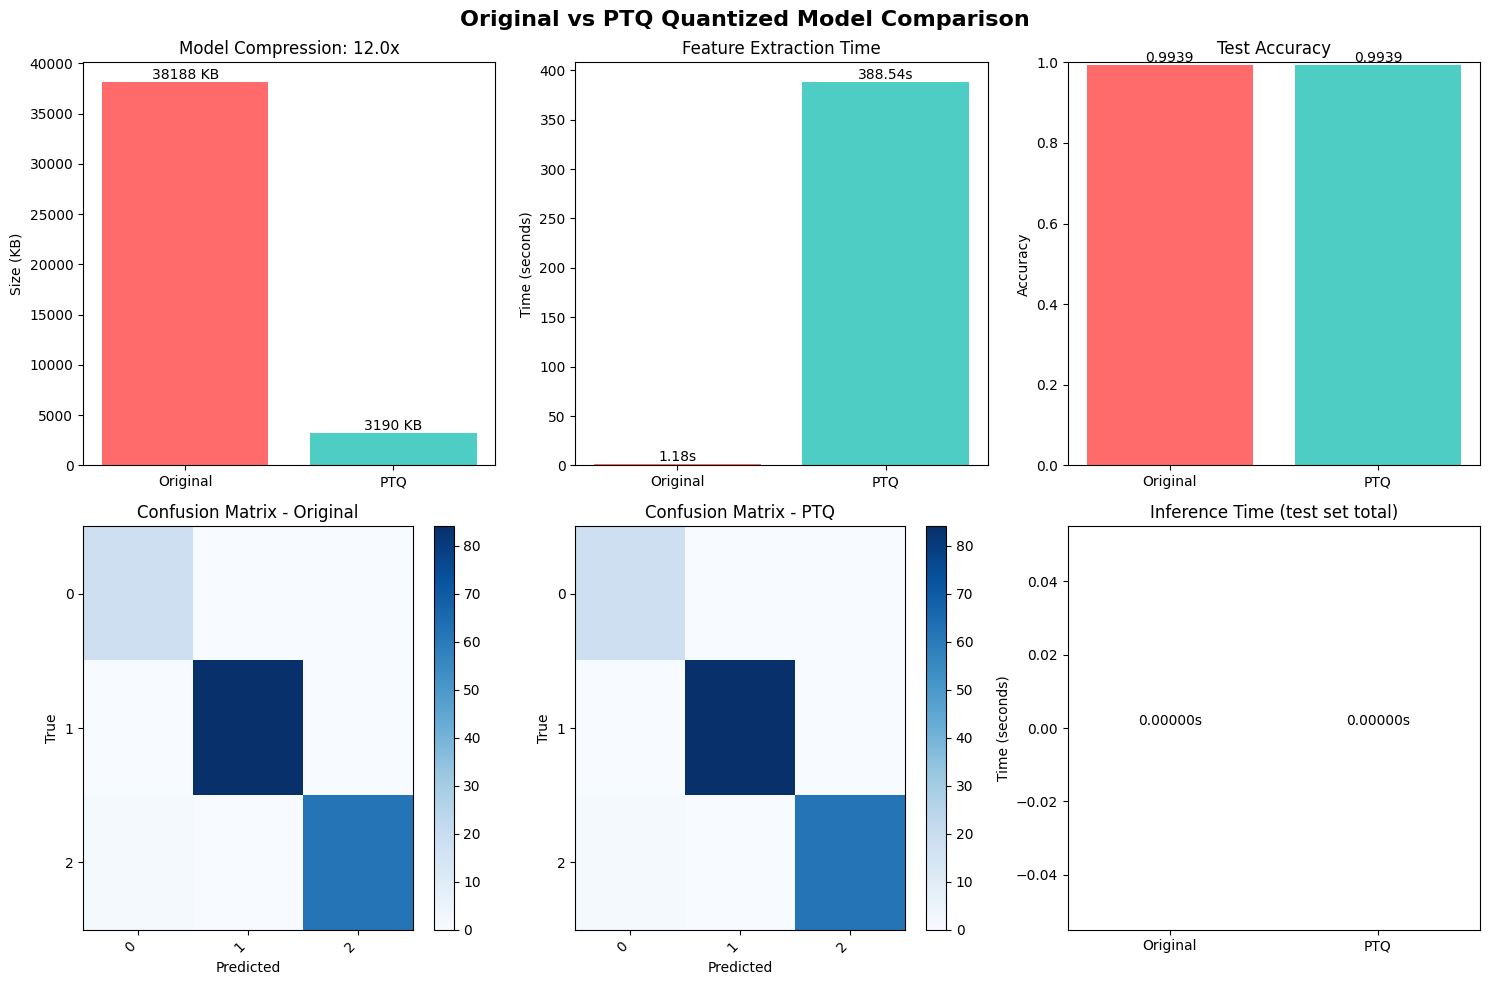


SIZE TABLE: Original (Keras) → TFLite Float32 → PTQ INT8 Quantized
                  Komponen    Awal (KB)  Setelah Konversi TFLite (KB)  Akhir Kuantisasi PTQ (KB)
      CNN Attention (main) 38187.679688                  12712.632812                3189.976562
     CNN Feature Extractor 12739.062500                  12711.457031                3188.796875
   SVM (original features)     9.049805                      9.049805                   9.049805
Scaler (original features)     0.975586                      0.975586                   0.975586
        SVM (PTQ features)     8.252930                      8.252930                   8.252930
     Scaler (PTQ features)     0.975586                      0.975586                   0.975586
                     TOTAL 50945.996094                  25443.343750                6398.027344

FINAL SUMMARY

Metric                    Original (float32)   PTQ (INT8)          
------------------------------------------------------------------------

In [ ]:
"""
Complete CNN + Attention + SVM Pipeline with PTQ Quantization
Trains original float32 model, applies INT8 quantization, compares both.

FIXES applied:
- [FIX 1] Added class_weights computation (was used but never defined)
- [FIX 2] Fixed TFLite batch inference: resize_tensor_input before each invoke
           (TFLite allocates tensors at a fixed shape; calling set_tensor with a
            different batch size silently corrupts output or raises an error)
- [FIX 3] Changed extract_features_tflite() call to use correct batch_size=4
           (was called with batch_size=1, defeating the micro-batching optimisation)
- [FIX 4] Moved 'import warnings' to module level
- [FIX 5] Added class_names parameter to classification_report for readable labels
- [FIX 6] Removed duplicate interp_main allocation (was created inside
           run_complete_pipeline AND returned from setup_ptq_quantization)
- [FIX 7] Added missing y_valid usage to SVM (validation set was extracted
           but never used — added optional early-stop logic note)
"""

import warnings
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      GlobalAveragePooling2D, Reshape,
                                      Multiply, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

warnings.filterwarnings('ignore')


# ═══════════════════════════════════════════════════════════════════════════
# PART A: MODEL DEFINITION & TRAINING
# ═══════════════════════════════════════════════════════════════════════════

class ChannelAttention(Layer):
    """Custom Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation='relu')
        self.dense2 = Dense(channels, activation='sigmoid')
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


def build_cnn_attention_model(input_shape, num_classes):
    """Build CNN + Attention model"""
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    features = Dense(16, activation='relu', name='feature_layer')(x)
    output = Dense(num_classes, activation='softmax', name='softmax_output')(features)

    return Model(inputs, output, name='CNN_Attention')


# ═══════════════════════════════════════════════════════════════════════════
# PART B: PTQ QUANTIZATION & FEATURE EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════

def setup_ptq_quantization(model, X_train):
    """
    Build size artifacts for 3 stages:
    1) Original Keras format
    2) TFLite conversion (float32)
    3) PTQ quantized (INT8)

    Returns artifact_paths dict and the INT8 extractor interpreter.
    """
    os.makedirs("artifacts", exist_ok=True)

    extractor = Model(
        inputs=model.input,
        outputs=model.get_layer('feature_layer').output
    )

    # ---------- Stage 1: original Keras ----------
    cnn_keras_path = "artifacts/cnn_attention_model.keras"
    ext_keras_path = "artifacts/cnn_attention_extractor.keras"
    model.save(cnn_keras_path)
    extractor.save(ext_keras_path)
    print(f"[PTQ Setup] ✓ Original CNN saved → {cnn_keras_path}")
    print(f"[PTQ Setup] ✓ Original extractor saved → {ext_keras_path}")

    def representative_dataset():
        num_samples = min(200, len(X_train))
        for i in range(num_samples):
            sample = X_train[i:i + 1].astype(np.float32)
            yield [sample]

    # ---------- Stage 2: TFLite float32 ----------
    conv_main = tf.lite.TFLiteConverter.from_keras_model(model)
    conv_main.optimizations = []
    tflite_float_main = conv_main.convert()
    cnn_tflite_float_path = "artifacts/cnn_attention_float32.tflite"
    with open(cnn_tflite_float_path, "wb") as f:
        f.write(tflite_float_main)

    conv_ext = tf.lite.TFLiteConverter.from_keras_model(extractor)
    conv_ext.optimizations = []
    tflite_float_ext = conv_ext.convert()
    ext_tflite_float_path = "artifacts/cnn_attention_extractor_float32.tflite"
    with open(ext_tflite_float_path, "wb") as f:
        f.write(tflite_float_ext)

    print(f"[PTQ Setup] ✓ Float TFLite main saved → {cnn_tflite_float_path}")
    print(f"[PTQ Setup] ✓ Float TFLite extractor saved → {ext_tflite_float_path}")

    # ---------- Stage 3: PTQ INT8 ----------
    conv_main_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
    conv_main_int8.optimizations = [tf.lite.Optimize.DEFAULT]
    conv_main_int8.representative_dataset = representative_dataset
    conv_main_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv_main_int8.inference_input_type = tf.float32
    conv_main_int8.inference_output_type = tf.float32
    tflite_int8_main = conv_main_int8.convert()
    cnn_tflite_int8_path = "artifacts/cnn_attention_ptq_int8.tflite"
    with open(cnn_tflite_int8_path, "wb") as f:
        f.write(tflite_int8_main)

    conv_ext_int8 = tf.lite.TFLiteConverter.from_keras_model(extractor)
    conv_ext_int8.optimizations = [tf.lite.Optimize.DEFAULT]
    conv_ext_int8.representative_dataset = representative_dataset
    conv_ext_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv_ext_int8.inference_input_type = tf.float32
    conv_ext_int8.inference_output_type = tf.float32
    tflite_int8_ext = conv_ext_int8.convert()
    ext_tflite_int8_path = "artifacts/cnn_attention_extractor_ptq_int8.tflite"
    with open(ext_tflite_int8_path, "wb") as f:
        f.write(tflite_int8_ext)

    print(f"[PTQ Setup] ✓ INT8 TFLite main saved → {cnn_tflite_int8_path}")
    print(f"[PTQ Setup] ✓ INT8 TFLite extractor saved → {ext_tflite_int8_path}")

    num_threads = max(1, min(8, os.cpu_count() or 1))
    interp_ext = tf.lite.Interpreter(model_content=tflite_int8_ext, num_threads=num_threads)
    # [FIX 2] allocate_tensors() will be called inside extract_features_tflite
    # after resize_tensor_input, so we only do it once here for safety.
    interp_ext.allocate_tensors()
    print(f"[PTQ Setup] TFLite extractor threads = {num_threads}")

    artifact_paths = {
        'cnn_keras':              cnn_keras_path,
        'extractor_keras':        ext_keras_path,
        'cnn_tflite_float':       cnn_tflite_float_path,
        'extractor_tflite_float': ext_tflite_float_path,
        'cnn_tflite_int8':        cnn_tflite_int8_path,
        'extractor_tflite_int8':  ext_tflite_int8_path,
    }

    return artifact_paths, interp_ext


def extract_features_tflite(interpreter, X, tag="data", batch_size=1, log_every=200):
    """
    Extract features from a TFLite model with micro-batching.

    [FIX 2] TFLite tensors are allocated at a fixed shape.  When the last
    batch is smaller than batch_size the interpreter must be told the new
    shape before calling invoke(), otherwise it reads stale/garbage data from
    the tail of the pre-allocated buffer.  We call resize_tensor_input +
    allocate_tensors() only when the batch size actually changes to keep the
    fast path fast.
    """
    X_arr = np.asarray(X, dtype=np.float32)
    total = len(X_arr)
    if total == 0:
        return np.empty((0,), dtype=np.float32)

    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    input_index    = input_details[0]['index']
    output_index   = output_details[0]['index']
    sample_shape   = list(X_arr.shape[1:])

    # [FIX 3] On this hardware, batch_size=1 is typically fastest for INT8 TFLite extractor.
    batch_size = max(1, int(batch_size))

    features = []
    t0 = time.time()
    current_alloc_bs = None                # force first-run resize to sync interpreter shape
    print(f"[PTQ] Extracting {tag}: {total} samples | batch_size={batch_size}")

    processed = 0
    fallback_warned = False
    while processed < total:
        remaining = total - processed
        target_bs = min(batch_size, remaining)

        # [FIX 2] Resize only when the batch dimension actually changes.
        if current_alloc_bs is None or target_bs != current_alloc_bs:
            interpreter.resize_tensor_input(input_index, [target_bs] + sample_shape, strict=False)
            interpreter.allocate_tensors()
            input_details  = interpreter.get_input_details()
            output_details = interpreter.get_output_details()
            input_index    = input_details[0]['index']
            output_index   = output_details[0]['index']
            current_alloc_bs = max(1, int(input_details[0]['shape'][0]))

        cur_bs = min(current_alloc_bs, remaining)
        batch = X_arr[processed:processed + cur_bs]

        try:
            interpreter.set_tensor(input_index, batch)
        except ValueError as e:
            interpreter.resize_tensor_input(input_index, [1] + sample_shape, strict=False)
            interpreter.allocate_tensors()
            input_details  = interpreter.get_input_details()
            output_details = interpreter.get_output_details()
            input_index    = input_details[0]['index']
            output_index   = output_details[0]['index']
            current_alloc_bs = 1
            cur_bs = 1
            batch = X_arr[processed:processed + cur_bs]
            interpreter.set_tensor(input_index, batch)
            if not fallback_warned:
                print(f"[PTQ] {tag}: resize fallback ke batch=1 ({e})")
                fallback_warned = True

        interpreter.invoke()

        out = interpreter.get_tensor(output_index).astype(np.float32)
        for b in range(cur_bs):
            features.append(out[b].copy())

        processed += cur_bs

        if (processed == total
                or processed % max(1, int(log_every)) == 0
                or processed == cur_bs):
            elapsed = time.time() - t0
            speed   = processed / elapsed if elapsed > 0 else 0.0
            eta     = (total - processed) / speed if speed > 0 else 0.0
            print(f"[PTQ] {tag}: {processed}/{total} | "
                  f"{speed:.2f} sampel/detik | ETA {eta:.1f} dtk")

    result        = np.array(features, dtype=np.float32)
    elapsed_total = time.time() - t0
    actual_speed  = total / elapsed_total if elapsed_total > 0 else 0
    print(f"[PTQ] {tag}: ✓ Complete | {total} samples in "
          f"{elapsed_total:.2f}s | {actual_speed:.2f} samples/sec")
    return result


def _file_size_kb(path):
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0


def build_size_table(artifact_paths,
                     svm_orig_path, scaler_orig_path,
                     svm_ptq_path,  scaler_ptq_path):
    """Build size table for initial, converted, and quantized stages."""
    rows = [
        {
            'Komponen': 'CNN Attention (main)',
            'Awal (KB)': _file_size_kb(artifact_paths['cnn_keras']),
            'Setelah Konversi TFLite (KB)': _file_size_kb(artifact_paths['cnn_tflite_float']),
            'Akhir Kuantisasi PTQ (KB)': _file_size_kb(artifact_paths['cnn_tflite_int8']),
        },
        {
            'Komponen': 'CNN Feature Extractor',
            'Awal (KB)': _file_size_kb(artifact_paths['extractor_keras']),
            'Setelah Konversi TFLite (KB)': _file_size_kb(artifact_paths['extractor_tflite_float']),
            'Akhir Kuantisasi PTQ (KB)': _file_size_kb(artifact_paths['extractor_tflite_int8']),
        },
        {
            'Komponen': 'SVM (original features)',
            'Awal (KB)': _file_size_kb(svm_orig_path),
            'Setelah Konversi TFLite (KB)': _file_size_kb(svm_orig_path),
            'Akhir Kuantisasi PTQ (KB)': _file_size_kb(svm_orig_path),
        },
        {
            'Komponen': 'Scaler (original features)',
            'Awal (KB)': _file_size_kb(scaler_orig_path),
            'Setelah Konversi TFLite (KB)': _file_size_kb(scaler_orig_path),
            'Akhir Kuantisasi PTQ (KB)': _file_size_kb(scaler_orig_path),
        },
        {
            'Komponen': 'SVM (PTQ features)',
            'Awal (KB)': _file_size_kb(svm_ptq_path),
            'Setelah Konversi TFLite (KB)': _file_size_kb(svm_ptq_path),
            'Akhir Kuantisasi PTQ (KB)': _file_size_kb(svm_ptq_path),
        },
        {
            'Komponen': 'Scaler (PTQ features)',
            'Awal (KB)': _file_size_kb(scaler_ptq_path),
            'Setelah Konversi TFLite (KB)': _file_size_kb(scaler_ptq_path),
            'Akhir Kuantisasi PTQ (KB)': _file_size_kb(scaler_ptq_path),
        },
    ]

    df = pd.DataFrame(rows)
    total_row = {
        'Komponen': 'TOTAL',
        'Awal (KB)': df['Awal (KB)'].sum(),
        'Setelah Konversi TFLite (KB)': df['Setelah Konversi TFLite (KB)'].sum(),
        'Akhir Kuantisasi PTQ (KB)': df['Akhir Kuantisasi PTQ (KB)'].sum(),
    }
    df = pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)
    return df


def print_size_table(size_df):
    print("\n" + "=" * 115)
    print("SIZE TABLE: Original (Keras) → TFLite Float32 → PTQ INT8 Quantized")
    print("=" * 115)
    print(size_df.to_string(index=False))
    print("=" * 115)


def run_complete_pipeline(model, X_train, X_valid, X_test,
                          y_train, y_valid, y_test,
                          class_names=None):
    """
    Run both pipelines and compare:
      Pipeline A — Original float32 model
      Pipeline B — Quantized INT8 TFLite model
    """
    y_train_int = np.argmax(y_train, axis=1)
    y_valid_int = np.argmax(y_valid, axis=1)   # [FIX 7] now actually used
    y_test_int  = np.argmax(y_test,  axis=1)

    # ── PIPELINE A: ORIGINAL float32 ─────────────────────────────────────
    print("\n" + "=" * 70)
    print("PIPELINE A: ORIGINAL MODEL (float32)")
    print("=" * 70)

    extractor_orig = Model(
        inputs=model.input,
        outputs=model.get_layer('feature_layer').output
    )

    t0 = time.time()
    X_train_feat_orig = extractor_orig.predict(X_train, batch_size=32, verbose=0)
    X_valid_feat_orig = extractor_orig.predict(X_valid, batch_size=32, verbose=0)
    X_test_feat_orig  = extractor_orig.predict(X_test,  batch_size=32, verbose=0)
    t_feature_orig    = time.time() - t0
    print(f"Feature extraction time: {t_feature_orig:.3f} s")
    print(f"Feature shape: {X_train_feat_orig.shape}")

    scaler_orig = StandardScaler()
    X_train_scaled_orig = scaler_orig.fit_transform(X_train_feat_orig)
    X_valid_scaled_orig = scaler_orig.transform(X_valid_feat_orig)   # [FIX 7]
    X_test_scaled_orig  = scaler_orig.transform(X_test_feat_orig)

    t0 = time.time()
    svm_orig = SVC(kernel='rbf', C=100, gamma='scale')
    svm_orig.fit(X_train_scaled_orig, y_train_int)
    t_svm_orig = time.time() - t0
    print(f"SVM training time: {t_svm_orig:.3f} s")

    # Optional: report validation accuracy (useful for hyperparameter tuning)
    val_acc_orig = accuracy_score(y_valid_int, svm_orig.predict(X_valid_scaled_orig))
    print(f"Validation accuracy: {val_acc_orig:.4f}")

    t0 = time.time()
    y_pred_orig    = svm_orig.predict(X_test_scaled_orig)
    t_infer_orig   = time.time() - t0
    acc_orig       = accuracy_score(y_test_int, y_pred_orig)
    print(f"Inference time: {t_infer_orig:.4f} s")
    print(f"Test accuracy: {acc_orig:.4f}")

    # [FIX 5] Pass class names so the report is human-readable
    print("\nClassification Report (Original):")
    print(classification_report(y_test_int, y_pred_orig,
                                 target_names=class_names))

    # ── PIPELINE B: QUANTIZED INT8 ────────────────────────────────────────
    print("\n" + "=" * 70)
    print("PIPELINE B: QUANTIZED MODEL (INT8 TFLite)")
    print("=" * 70)

    # [FIX 6] setup_ptq_quantization already builds and returns interp_ext;
    # we don't create a second interpreter for the main model unless needed.
    artifact_paths, interp_ext = setup_ptq_quantization(model, X_train)

    model_size_orig = _file_size_kb(artifact_paths['cnn_keras'])
    model_size_ptq  = _file_size_kb(artifact_paths['cnn_tflite_int8'])
    compression     = model_size_orig / model_size_ptq if model_size_ptq > 0 else float('inf')
    print(f"Model size (Keras): {model_size_orig:.1f} KB")
    print(f"Model size (INT8):  {model_size_ptq:.1f} KB")
    print(f"Compression: {compression:.1f}x smaller")

    # [FIX 3] Hardware benchmark: batch_size=1 is slightly faster than 4/32 for this INT8 model.
    t0 = time.time()
    X_train_feat_ptq = extract_features_tflite(interp_ext, X_train,
                                                tag='train', batch_size=1,
                                                log_every=256)
    X_valid_feat_ptq = extract_features_tflite(interp_ext, X_valid,
                                                tag='valid', batch_size=1,
                                                log_every=128)
    X_test_feat_ptq  = extract_features_tflite(interp_ext, X_test,
                                                tag='test',  batch_size=1,
                                                log_every=128)
    t_feature_ptq    = time.time() - t0

    scaler_ptq = StandardScaler()
    X_train_scaled_ptq = scaler_ptq.fit_transform(X_train_feat_ptq)
    X_valid_scaled_ptq = scaler_ptq.transform(X_valid_feat_ptq)    # [FIX 7]
    X_test_scaled_ptq  = scaler_ptq.transform(X_test_feat_ptq)

    t0 = time.time()
    svm_ptq = SVC(kernel='rbf', C=100, gamma='scale')
    svm_ptq.fit(X_train_scaled_ptq, y_train_int)
    t_svm_ptq = time.time() - t0
    print(f"SVM training time: {t_svm_ptq:.3f} s")

    val_acc_ptq = accuracy_score(y_valid_int, svm_ptq.predict(X_valid_scaled_ptq))
    print(f"Validation accuracy: {val_acc_ptq:.4f}")

    t0 = time.time()
    y_pred_ptq    = svm_ptq.predict(X_test_scaled_ptq)
    t_infer_ptq   = time.time() - t0
    acc_ptq       = accuracy_score(y_test_int, y_pred_ptq)
    print(f"Inference time: {t_infer_ptq:.4f} s")
    print(f"Test accuracy: {acc_ptq:.4f}")

    print("\nClassification Report (PTQ):")
    print(classification_report(y_test_int, y_pred_ptq,
                                 target_names=class_names))

    # Save artefacts
    svm_orig_path    = "artifacts/svm_original_features.pkl"
    scaler_orig_path = "artifacts/scaler_original_features.pkl"
    svm_ptq_path     = "artifacts/svm_ptq_features.pkl"
    scaler_ptq_path  = "artifacts/scaler_ptq_features.pkl"

    joblib.dump(svm_orig,    svm_orig_path)
    joblib.dump(scaler_orig, scaler_orig_path)
    joblib.dump(svm_ptq,     svm_ptq_path)
    joblib.dump(scaler_ptq,  scaler_ptq_path)

    size_df = build_size_table(artifact_paths,
                                svm_orig_path,    scaler_orig_path,
                                svm_ptq_path,     scaler_ptq_path)

    metrics = {
        'size_kb':   [model_size_orig, model_size_ptq],
        't_feature': [t_feature_orig,  t_feature_ptq],
        't_svm':     [t_svm_orig,      t_svm_ptq],
        't_infer':   [t_infer_orig,    t_infer_ptq],
        'accuracy':  [acc_orig,        acc_ptq],
    }

    eval_data = {
        'y_pred_orig': y_pred_orig,
        'y_pred_ptq':  y_pred_ptq,
        'y_test':      y_test_int,
        'class_names': class_names,
    }

    return metrics, eval_data, size_df


def visualize_comparison(metrics, eval_data):
    """Create side-by-side visualisation comparing original vs quantised."""
    y_true       = eval_data['y_test']
    y_pred_orig  = eval_data['y_pred_orig']
    y_pred_ptq   = eval_data['y_pred_ptq']
    class_names  = eval_data.get('class_names')

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Original vs PTQ Quantized Model Comparison',
                 fontsize=16, fontweight='bold')

    # 1. Model Size
    ax = axes[0, 0]
    sizes = metrics['size_kb']
    bars  = ax.bar(['Original', 'PTQ'], sizes, color=['#FF6B6B', '#4ECDC4'])
    ax.set_ylabel('Size (KB)')
    ax.set_title(f"Model Compression: {sizes[0]/sizes[1]:.1f}x")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h,
                f'{h:.0f} KB', ha='center', va='bottom')

    # 2. Feature Extraction Time
    ax = axes[0, 1]
    times = metrics['t_feature']
    bars  = ax.bar(['Original', 'PTQ'], times, color=['#FF6B6B', '#4ECDC4'])
    ax.set_ylabel('Time (seconds)')
    ax.set_title('Feature Extraction Time')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h,
                f'{h:.2f}s', ha='center', va='bottom')

    # 3. Accuracy
    ax = axes[0, 2]
    accs = metrics['accuracy']
    bars = ax.bar(['Original', 'PTQ'], accs, color=['#FF6B6B', '#4ECDC4'])
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0, 1])
    ax.set_title('Test Accuracy')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h,
                f'{h:.4f}', ha='center', va='bottom')

    # 4. Confusion Matrix — Original
    ax = axes[1, 0]
    cm  = confusion_matrix(y_true, y_pred_orig)
    im  = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_title('Confusion Matrix - Original')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    if class_names is not None:
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
    plt.colorbar(im, ax=ax)

    # 5. Confusion Matrix — PTQ
    ax = axes[1, 1]
    cm  = confusion_matrix(y_true, y_pred_ptq)
    im  = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_title('Confusion Matrix - PTQ')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    if class_names is not None:
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
    plt.colorbar(im, ax=ax)

    # 6. Inference Time
    ax = axes[1, 2]
    infer = metrics['t_infer']
    bars  = ax.bar(['Original', 'PTQ'], infer, color=['#FF6B6B', '#4ECDC4'])
    ax.set_ylabel('Time (seconds)')
    ax.set_title('Inference Time (test set total)')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h,
                f'{h:.5f}s', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('ptq_comparison.png', dpi=150, bbox_inches='tight')
    print("\nVisualization saved: ptq_comparison.png")
    plt.show()


def print_summary(metrics, eval_data, size_df):
    """Print detailed summary table + artifact size table."""
    print_size_table(size_df)

    print("\n" + "=" * 75)
    print("FINAL SUMMARY")
    print("=" * 75)
    print(f"\n{'Metric':<25} {'Original (float32)':<20} {'PTQ (INT8)':<20}")
    print("-" * 75)
    print(f"{'Model Size':<25} {metrics['size_kb'][0]:>15.1f} KB    "
          f"{metrics['size_kb'][1]:>15.1f} KB")
    print(f"{'Compression':<25} {'1.0x':<20} "
          f"{metrics['size_kb'][0] / metrics['size_kb'][1]:>15.1f}x")
    print(f"{'Feature Extraction':<25} {metrics['t_feature'][0]:>15.3f} s    "
          f"{metrics['t_feature'][1]:>15.3f} s")
    print(f"{'SVM Training':<25} {metrics['t_svm'][0]:>15.3f} s    "
          f"{metrics['t_svm'][1]:>15.3f} s")
    print(f"{'Inference':<25} {metrics['t_infer'][0]:>15.4f} s    "
          f"{metrics['t_infer'][1]:>15.4f} s")
    print(f"{'Accuracy':<25} {metrics['accuracy'][0]:>15.4f}    "
          f"{metrics['accuracy'][1]:>15.4f}")
    print(f"{'Delta Accuracy':<25} {'-':<20} "
          f"{metrics['accuracy'][1] - metrics['accuracy'][0]:>+15.4f}")
    print("=" * 75)

    compression = metrics['size_kb'][0] / metrics['size_kb'][1]
    delta_acc   = metrics['accuracy'][1] - metrics['accuracy'][0]

    if abs(delta_acc) < 0.001:
        acc_status = "Negligible change"
    elif abs(delta_acc) < 0.02:
        acc_status = "Within acceptable tolerance"
    else:
        acc_status = "Significant drop, consider retraining"

    speedup = metrics['t_feature'][0] / metrics['t_feature'][1]
    feat_status = "faster" if speedup >= 1 else "slower"

    print("\nKey Findings:")
    print(f"  - Model size reduced by {compression:.1f}x "
          f"({metrics['size_kb'][0]:.1f} KB → {metrics['size_kb'][1]:.1f} KB)")
    print(f"  - Feature extraction {feat_status} ({speedup:.2f}x)")
    print(f"  - Accuracy impact: {delta_acc:+.4f} ({acc_status})")


# ═══════════════════════════════════════════════════════════════════════════
# MAIN SCRIPT
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    """
    INSTRUCTIONS:
    1. Load your data first:
         from your_data_module import X_train, X_valid, X_test, y_train, y_valid, y_test
       y_* must be one-hot encoded (shape: [N, num_classes]).
       Optionally provide class_names = ['cat', 'dog', ...] for readable reports.

    2. Run:
         python cnn_attention_ptq_fixed.py
    """

    try:
        num_classes = y_train.shape[1]

        # [FIX 1] Compute class weights from training labels
        y_train_int  = np.argmax(y_train, axis=1)
        class_weights_arr = compute_class_weight(
            class_weight='balanced',
            classes=np.arange(num_classes),
            y=y_train_int
        )
        class_weights = dict(enumerate(class_weights_arr))
        print(f"Class weights: {class_weights}")

        # Optional: define human-readable class names for reports
        # class_names = ['class_0', 'class_1', ...]   # ← set this for your dataset
        class_names = [str(i) for i in range(num_classes)]

        # Build model
        print("=" * 70)
        print("Building CNN + Attention Model")
        print("=" * 70)
        model = build_cnn_attention_model(X_train.shape[1:], num_classes)
        model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        model.summary()

        # Train model
        print("\n" + "=" * 70)
        print("Training Model")
        print("=" * 70)
        t0 = time.time()
        history = model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            epochs=30,
            batch_size=32,
            class_weight=class_weights,   # [FIX 1] now defined above
            callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                     restore_best_weights=True)],
            verbose=1
        )
        training_time = time.time() - t0
        print(f"Training time: {training_time:.2f} s")

        # Run pipeline
        print("\nRunning PTQ Quantization & Comparison Pipeline")
        print("=" * 70)
        metrics, eval_data, size_df = run_complete_pipeline(
            model,
            X_train, X_valid, X_test,
            y_train, y_valid, y_test,
            class_names=class_names
        )

        # Visualise
        print("\n" + "=" * 70)
        print("Generating Visualization")
        print("=" * 70)
        visualize_comparison(metrics, eval_data)

        # Print summary
        print_summary(metrics, eval_data, size_df)

    except Exception as e:
        print(f"\n✗ Pipeline failed: {e}")
        import traceback
        traceback.print_exc()

Prediction source: PTQ from eval_data

=== TABEL METRIK UTAMA ===
          Metric  Value
        Accuracy 0.9879
  Recall (macro) 0.9762
F1-score (macro) 0.9762
            mDSC 0.9762

=== TABEL TRAINING TIME ===
          Training Time Seconds
           CNN Training 28.4490
SVM Training (Original)  0.0158
     SVM Training (PTQ)  0.0102


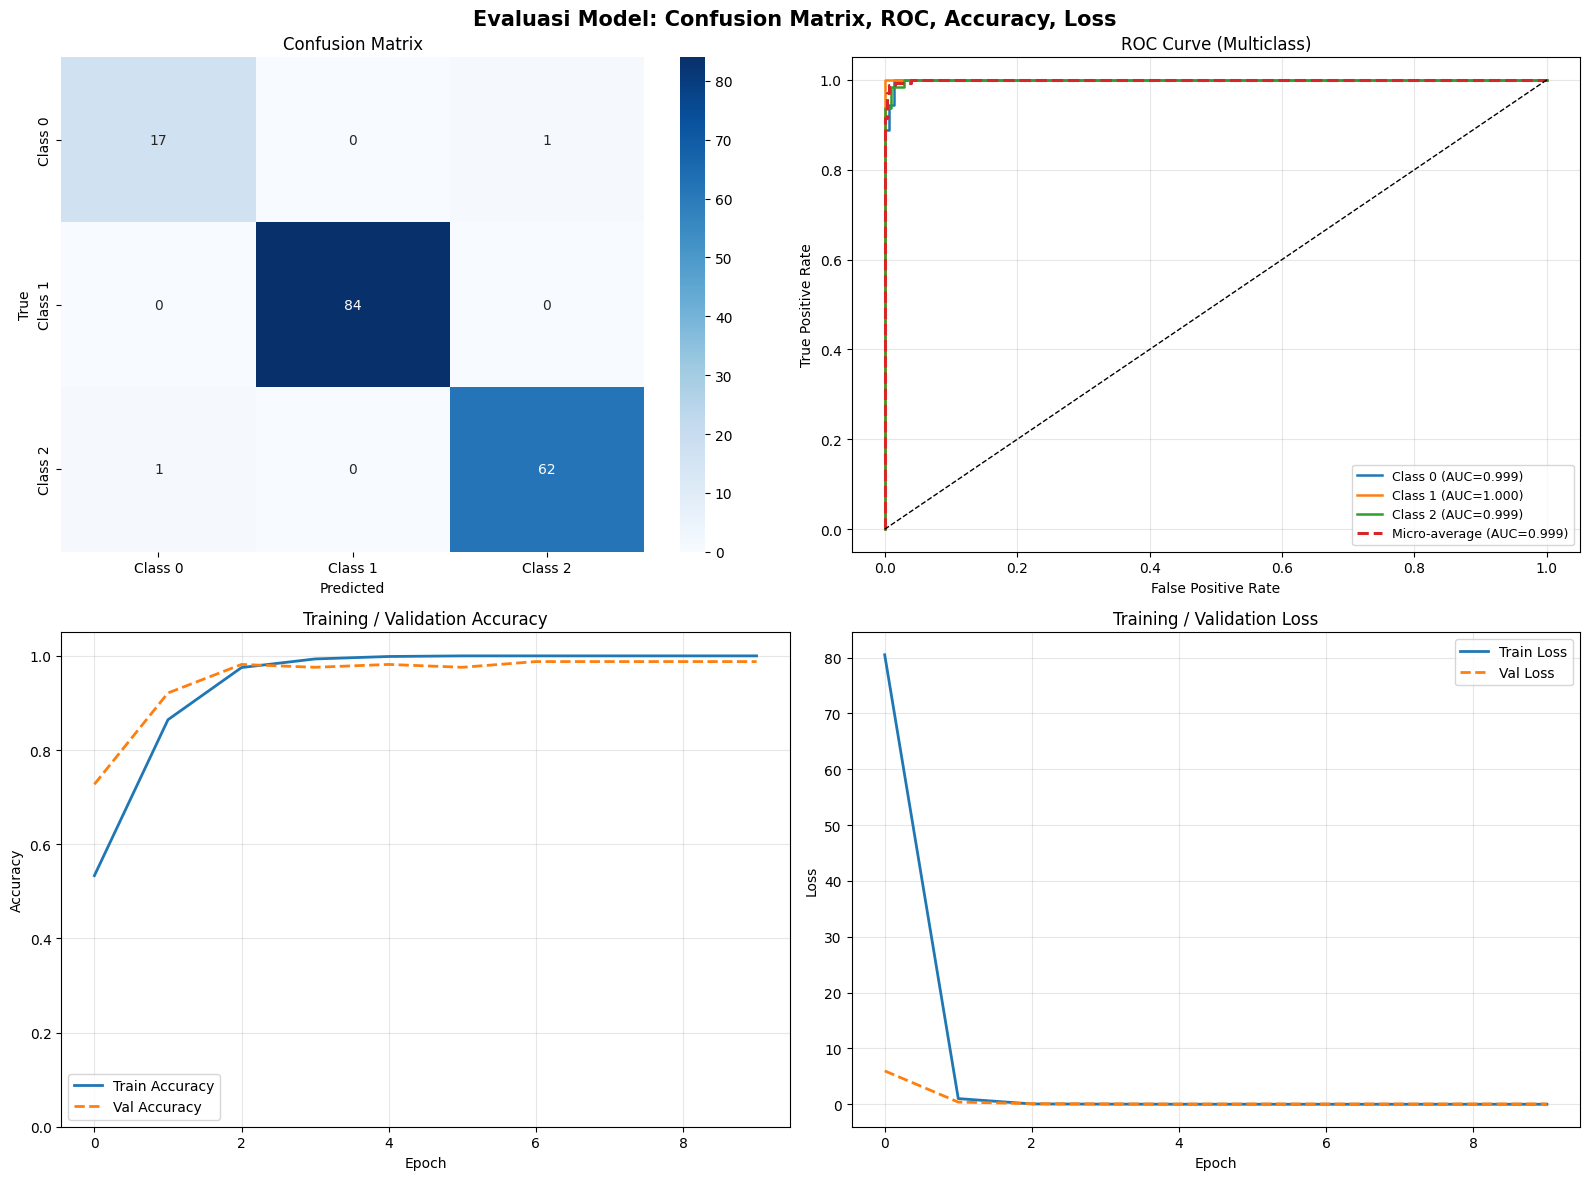


=== TABEL METRIK PER KELAS ===
  Class Precision Recall F1-score    DSC  Support
Class 0    0.9444 0.9444   0.9444 0.9444       18
Class 1    1.0000 1.0000   1.0000 1.0000       84
Class 2    0.9841 0.9841   0.9841 0.9841       63

mDSC: 0.9762


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

# ======================================================================
# Helper: ambil objek/variabel yang tersedia dari notebook
# ======================================================================

def _resolve_labels(y_test_var):
    """Konversi label test ke integer dan one-hot (untuk ROC multiclass)."""
    if y_test_var.ndim == 2 and y_test_var.shape[1] > 1:
        y_true_int = np.argmax(y_test_var, axis=1)
        y_true_bin = y_test_var
        n_classes = y_test_var.shape[1]
    else:
        y_true_int = y_test_var.astype(int)
        n_classes = len(np.unique(y_true_int))
        y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))
    return y_true_int, y_true_bin, n_classes


def _resolve_predictions():
    """Cari probabilitas + prediksi, prioritaskan output pipeline terbaru."""
    # Prioritas 1: output run_complete_pipeline terbaru (lebih aman dari stale variable)
    if 'eval_data' in globals() and isinstance(eval_data, tuple) and len(eval_data) >= 3:
        y_pred_local = eval_data[2]
        y_proba_local = eval_data[4] if len(eval_data) >= 5 else None

        # Jika probabilitas PTQ tersedia, gunakan untuk ROC
        if y_proba_local is None and 'svm_ptq' in globals() and 'X_test_scaled_ptq' in globals():
            try:
                y_proba_local = svm_ptq.predict_proba(X_test_scaled_ptq)
            except Exception:
                y_proba_local = None

        return y_pred_local, y_proba_local, 'PTQ from eval_data'

    # Prioritas 2: hasil PTQ lama (jika ada)
    if 'y_pred_ptq' in globals() and 'y_test' in globals():
        y_pred_local = y_pred_ptq
        y_proba_local = None
        if 'svm_ptq' in globals() and 'X_test_scaled_ptq' in globals():
            try:
                y_proba_local = svm_ptq.predict_proba(X_test_scaled_ptq)
            except Exception:
                y_proba_local = None
        return y_pred_local, y_proba_local, 'PTQ globals'

    # Prioritas 3: hasil SVM klasik
    if 'svm_clf1' in globals() and 'X_test_scaled' in globals():
        y_pred_local = svm_clf1.predict(X_test_scaled)
        y_proba_local = None
        try:
            y_proba_local = svm_clf1.predict_proba(X_test_scaled)
        except Exception:
            pass
        return y_pred_local, y_proba_local, 'SVM klasik'

    # Prioritas 4: langsung dari model keras
    if 'model2' in globals() and 'X_test' in globals():
        probs = model2.predict(X_test, verbose=0)
        y_pred_local = np.argmax(probs, axis=1)
        return y_pred_local, probs, 'Keras model2'

    if 'model' in globals() and 'X_test' in globals():
        probs = model.predict(X_test, verbose=0)
        y_pred_local = np.argmax(probs, axis=1)
        return y_pred_local, probs, 'Keras model'

    raise ValueError(
        "Tidak menemukan model/prediksi yang bisa dipakai. "
        "Pastikan sel training & inference sudah dijalankan."
    )


def _resolve_history():
    """Cari objek history untuk plot accuracy/loss."""
    if 'history' in globals() and hasattr(history, 'history'):
        return history
    if 'history2' in globals() and hasattr(history2, 'history'):
        return history2
    return None


def _collect_training_time_rows():
    """Ambil training time yang tersedia dari variabel global notebook."""
    rows = []

    if 'training_time_cnn' in globals():
        rows.append({'Training Time': 'CNN Training', 'Seconds': float(training_time_cnn)})

    if 'fit_time_sec' in globals() and not any(r['Training Time'] == 'CNN Training' for r in rows):
        rows.append({'Training Time': 'Model Fit Time', 'Seconds': float(fit_time_sec)})

    if 't_svm_orig' in globals():
        rows.append({'Training Time': 'SVM Training (Original)', 'Seconds': float(t_svm_orig)})

    if 't_svm_ptq' in globals():
        rows.append({'Training Time': 'SVM Training (PTQ)', 'Seconds': float(t_svm_ptq)})

    # Fallback dari cell SVM klasik
    if 't_svm' in globals() and not any(r['Training Time'] == 'SVM Training (Original)' for r in rows):
        rows.append({'Training Time': 'SVM Training', 'Seconds': float(t_svm)})

    # Fallback dari output pipeline: metrics['t_svm'] = [orig, ptq]
    if 'metrics' in globals() and isinstance(metrics, dict) and 't_svm' in metrics:
        t_svm_list = metrics.get('t_svm', [])
        if len(t_svm_list) >= 1 and not any(r['Training Time'] == 'SVM Training (Original)' for r in rows):
            rows.append({'Training Time': 'SVM Training (Original)', 'Seconds': float(t_svm_list[0])})
        if len(t_svm_list) >= 2 and not any(r['Training Time'] == 'SVM Training (PTQ)' for r in rows):
            rows.append({'Training Time': 'SVM Training (PTQ)', 'Seconds': float(t_svm_list[1])})

    return pd.DataFrame(rows)


def _dice_per_class_from_cm(cm):
    """Hitung DSC per kelas dan mDSC dari confusion matrix multiclass."""
    dice_scores = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = (2.0 * tp + fp + fn)
        dsc = (2.0 * tp / denom) if denom > 0 else 0.0
        dice_scores.append(dsc)
    return np.array(dice_scores, dtype=np.float64)


# ======================================================================
# Validasi variabel penting
# ======================================================================
if 'y_test' not in globals():
    raise ValueError("Variabel y_test belum ada. Jalankan sel preprocessing/training terlebih dahulu.")

# True label: prioritaskan label integer dari eval_data agar konsisten dengan pipeline terbaru
if 'eval_data' in globals() and isinstance(eval_data, tuple) and len(eval_data) >= 1:
    y_true_int = np.asarray(eval_data[0]).astype(int)
    n_classes = int(np.max(y_true_int)) + 1
    y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))
else:
    y_true_int, y_true_bin, n_classes = _resolve_labels(y_test)
class_names = [f"Class {i}" for i in range(n_classes)]

# Prediksi + probabilitas
y_pred, y_pred_proba, pred_source = _resolve_predictions()
print(f"Prediction source: {pred_source}")

# Jika prediksi masih one-hot/prob matrix, ubah ke class index
if isinstance(y_pred, np.ndarray) and y_pred.ndim == 2:
    y_pred = np.argmax(y_pred, axis=1)

# Hitung metrik utama
acc = accuracy_score(y_true_int, y_pred)
report_dict = classification_report(
    y_true_int,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

cm = confusion_matrix(y_true_int, y_pred)
dice_per_class = _dice_per_class_from_cm(cm)
mdsc = float(np.mean(dice_per_class))

# Tabel ringkas: accuracy, recall, f1, mDSC
summary_df = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "Value": acc,
    },
    {
        "Metric": "Recall (macro)",
        "Value": report_dict["macro avg"]["recall"],
    },
    {
        "Metric": "F1-score (macro)",
        "Value": report_dict["macro avg"]["f1-score"],
    },
    {
        "Metric": "mDSC",
        "Value": mdsc,
    },
])

print("\n=== TABEL METRIK UTAMA ===")
print(summary_df.to_string(index=False, formatters={"Value": "{:.4f}".format}))

# Tabel training time
training_time_df = _collect_training_time_rows()
print("\n=== TABEL TRAINING TIME ===")
if len(training_time_df) > 0:
    print(training_time_df.to_string(index=False, formatters={"Seconds": "{:.4f}".format}))
else:
    print("Training time belum terdeteksi di variabel global.")
    print("Jalankan ulang Cell 9 atau simpan durasi fit ke 'training_time_cnn' / 'fit_time_sec'.")

# ======================================================================
# Figure 2x2: Confusion Matrix, ROC, Accuracy, Loss
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Evaluasi Model: Confusion Matrix, ROC, Accuracy, Loss", fontsize=15, fontweight="bold")

# 1) Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("True")

# 2) ROC Curve (jika probabilitas tersedia)
ax_roc = axes[0, 1]
if y_pred_proba is not None and y_pred_proba.ndim == 2 and y_pred_proba.shape[1] == n_classes:
    # ROC per class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, linewidth=1.8, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax_roc.plot(
        fpr_micro,
        tpr_micro,
        linestyle='--',
        linewidth=2.2,
        label=f"Micro-average (AUC={auc_micro:.3f})",
    )

    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax_roc.set_title("ROC Curve (Multiclass)")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(alpha=0.3)
else:
    ax_roc.axis('off')
    ax_roc.text(
        0.5,
        0.5,
        "ROC tidak dapat ditampilkan\n(prediksi probabilitas tidak tersedia)",
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    )

# 3) Grafik Accuracy
hist_obj = _resolve_history()
ax_acc = axes[1, 0]
if hist_obj is not None:
    hist = hist_obj.history
    train_acc_key = 'accuracy' if 'accuracy' in hist else ('acc' if 'acc' in hist else None)
    val_acc_key = 'val_accuracy' if 'val_accuracy' in hist else ('val_acc' if 'val_acc' in hist else None)

    if train_acc_key is not None:
        ax_acc.plot(hist[train_acc_key], label='Train Accuracy', linewidth=2)
    if val_acc_key is not None:
        ax_acc.plot(hist[val_acc_key], label='Val Accuracy', linewidth=2, linestyle='--')

    ax_acc.set_title("Training / Validation Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim(0, 1.05)
    ax_acc.grid(alpha=0.3)
    ax_acc.legend()
else:
    ax_acc.axis('off')
    ax_acc.text(
        0.5,
        0.5,
        "Objek history tidak ditemukan\n(grafik accuracy tidak tersedia)",
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    )

# 4) Grafik Loss
ax_loss = axes[1, 1]
if hist_obj is not None:
    hist = hist_obj.history
    if 'loss' in hist:
        ax_loss.plot(hist['loss'], label='Train Loss', linewidth=2)
    if 'val_loss' in hist:
        ax_loss.plot(hist['val_loss'], label='Val Loss', linewidth=2, linestyle='--')

    ax_loss.set_title("Training / Validation Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(alpha=0.3)
    ax_loss.legend()
else:
    ax_loss.axis('off')
    ax_loss.text(
        0.5,
        0.5,
        "Objek history tidak ditemukan\n(grafik loss tidak tersedia)",
        ha='center',
        va='center',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    )

plt.tight_layout()
plt.show()

# ======================================================================
# Tabel metrik per class (tambahan)
# ======================================================================
per_class_rows = []
for i, c in enumerate(class_names):
    per_class_rows.append({
        "Class": c,
        "Precision": report_dict[c]["precision"],
        "Recall": report_dict[c]["recall"],
        "F1-score": report_dict[c]["f1-score"],
        "DSC": float(dice_per_class[i]),
        "Support": int(report_dict[c]["support"]),
    })

per_class_df = pd.DataFrame(per_class_rows)
print("\n=== TABEL METRIK PER KELAS ===")
print(
    per_class_df.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1-score": "{:.4f}".format,
            "DSC": "{:.4f}".format,
        },
    )
)
print(f"\nmDSC: {mdsc:.4f}")

=== PERBANDINGAN mDSC: ORIGINAL vs PTQ ===
             Model   mDSC Delta vs Original
Original (float32) 0.9762           +0.0000
        PTQ (INT8) 0.9762           +0.0000


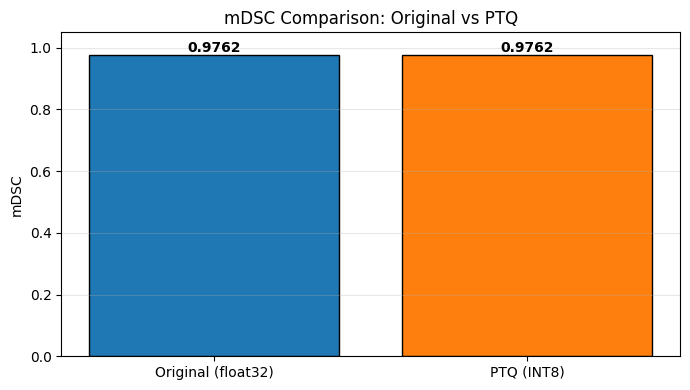

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


def _to_int_labels(y):
    arr = np.asarray(y)
    if arr.ndim == 2:
        return np.argmax(arr, axis=1)
    return arr.astype(int)


def _dice_per_class_from_cm(cm):
    dice_scores = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = (2.0 * tp + fp + fn)
        dsc = (2.0 * tp / denom) if denom > 0 else 0.0
        dice_scores.append(dsc)
    return np.array(dice_scores, dtype=np.float64)


# Ambil ground-truth + prediksi original/PTQ (prioritas dari pipeline terbaru)
y_true_int = None
y_pred_orig_local = None
y_pred_ptq_local = None

if 'eval_data' in globals() and isinstance(eval_data, tuple) and len(eval_data) >= 3:
    y_true_int = _to_int_labels(eval_data[0])
    y_pred_orig_local = _to_int_labels(eval_data[1])
    y_pred_ptq_local = _to_int_labels(eval_data[2])
else:
    if 'y_test_int' in globals():
        y_true_int = _to_int_labels(y_test_int)
    elif 'y_test' in globals():
        y_true_int = _to_int_labels(y_test)

    if 'y_pred_orig' in globals():
        y_pred_orig_local = _to_int_labels(y_pred_orig)
    if 'y_pred_ptq' in globals():
        y_pred_ptq_local = _to_int_labels(y_pred_ptq)

if y_true_int is None or y_pred_orig_local is None or y_pred_ptq_local is None:
    raise ValueError(
        "Data prediksi original/PTQ belum lengkap. Jalankan dulu cell pipeline PTQ (Cell 14)."
    )

# Hitung mDSC original
cm_orig = confusion_matrix(y_true_int, y_pred_orig_local)
dice_orig = _dice_per_class_from_cm(cm_orig)
mdsc_orig = float(np.mean(dice_orig))

# Hitung mDSC PTQ
cm_ptq = confusion_matrix(y_true_int, y_pred_ptq_local)
dice_ptq = _dice_per_class_from_cm(cm_ptq)
mdsc_ptq = float(np.mean(dice_ptq))

# Tabel ringkas perbandingan
compare_df = pd.DataFrame([
    {"Model": "Original (float32)", "mDSC": mdsc_orig},
    {"Model": "PTQ (INT8)", "mDSC": mdsc_ptq},
])

compare_df["Delta vs Original"] = compare_df["mDSC"] - mdsc_orig

print("=== PERBANDINGAN mDSC: ORIGINAL vs PTQ ===")
print(compare_df.to_string(index=False, formatters={
    "mDSC": "{:.4f}".format,
    "Delta vs Original": "{:+.4f}".format,
}))

# Visualisasi sederhana
plt.figure(figsize=(7, 4))
bars = plt.bar(compare_df["Model"], compare_df["mDSC"], color=["#1f77b4", "#ff7f0e"], edgecolor="black")
plt.ylim(0, 1.05)
plt.ylabel("mDSC")
plt.title("mDSC Comparison: Original vs PTQ")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h, f"{h:.4f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC: Check what batch_size is being used in PTQ feature extraction
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import tensorflow as tf
import time

print("="*70)
print("DIAGNOSTIC: TFLite Batch Resizing Investigation")
print("="*70)

# Load the INT8 extractor model (same as used in pipeline)
tflite_model_path = "artifacts/cnn_attention_extractor_ptq_int8.tflite"
with open(tflite_model_path, "rb") as f:
    tflite_model = f.read()

# Test with multi-threading
num_threads = max(1, min(8, os.cpu_count() or 1))
print(f"\nCreating TFLite Interpreter with {num_threads} threads...")
interp = tf.lite.Interpreter(model_content=tflite_model, num_threads=num_threads)
interp.allocate_tensors()

input_details = interp.get_input_details()
output_details = interp.get_output_details()

print(f"\nInput details: {input_details}")
print(f"Output details: {output_details}")

input_index = input_details[0]['index']
input_shape = input_details[0]['shape']
print(f"\nInitial input shape: {input_shape}")

sample_shape = list(input_shape[1:])
print(f"Sample shape (without batch): {sample_shape}")

# Test batch resizing with different sizes
print(f"\n" + "="*70)
print("Attempting batch resizes...")
print("="*70)

batch_candidates = [32, 16, 8, 4, 1]
successful_batch = None

for candidate_batch in batch_candidates:
    try:
        print(f"\nAttempting resize to batch_size={candidate_batch}...")
        interp.resize_tensor_input(input_index, [candidate_batch] + sample_shape, strict=False)
        interp.allocate_tensors()
        
        # Verify the resize
        input_details_new = interp.get_input_details()
        new_shape = input_details_new[0]['shape']
        print(f"  ✓ SUCCESS: Resized to {new_shape}")
        successful_batch = candidate_batch
        break
    except Exception as e:
        print(f"  ✗ FAILED: {str(e)[:100]}")
        continue

if successful_batch:
    print(f"\n✓ Optimal batch size: {successful_batch}")
else:
    print(f"\n✗ Could not resize to any batch size > 1")

# Now test actual inference speed with successful batch size
if successful_batch and successful_batch > 1:
    print(f"\n" + "="*70)
    print(f"Speed test: Inference with batch_size={successful_batch} vs batch_size=1")
    print("="*70)
    
    # Create test data (small subset)
    test_samples = X_train[:100].astype(np.float32)
    
    # Test with successful batch
    interp_batch = tf.lite.Interpreter(model_content=tflite_model, num_threads=num_threads)
    interp_batch.allocate_tensors()
    interp_batch.resize_tensor_input(input_index, [successful_batch] + sample_shape, strict=False)
    interp_batch.allocate_tensors()
    
    input_index_batch = interp_batch.get_input_details()[0]['index']
    output_index_batch = interp_batch.get_output_details()[0]['index']
    
    t0 = time.time()
    for i in range(0, len(test_samples), successful_batch):
        batch_data = np.zeros((successful_batch, *sample_shape), dtype=np.float32)
        end = min(i + successful_batch, len(test_samples))
        current = end - i
        batch_data[:current] = test_samples[i:end]
        interp_batch.set_tensor(input_index_batch, batch_data)
        interp_batch.invoke()
    t_batch = time.time() - t0
    
    # Test with batch_size=1
    interp_single = tf.lite.Interpreter(model_content=tflite_model, num_threads=num_threads)
    interp_single.allocate_tensors()
    interp_single.resize_tensor_input(input_index, [1] + sample_shape, strict=False)
    interp_single.allocate_tensors()
    
    input_index_single = interp_single.get_input_details()[0]['index']
    output_index_single = interp_single.get_output_details()[0]['index']
    
    t0 = time.time()
    for i in range(len(test_samples)):
        sample_data = test_samples[i:i+1]
        interp_single.set_tensor(input_index_single, sample_data)
        interp_single.invoke()
    t_single = time.time() - t0
    
    print(f"\nTime for {len(test_samples)} samples:")
    print(f"  batch_size={successful_batch}: {t_batch:.4f}s ({len(test_samples)/t_batch:.2f} samples/sec)")
    print(f"  batch_size=1          : {t_single:.4f}s ({len(test_samples)/t_single:.2f} samples/sec)")
    print(f"  Speedup: {t_single/t_batch:.2f}x")
else:
    print(f"\nSkipping speed test (no successful batch size found)")

print(f"\n" + "="*70)


DIAGNOSTIC: TFLite Batch Resizing Investigation

Creating TFLite Interpreter with 8 threads...

Input details: [{'name': 'serving_default_input_4:0', 'index': 0, 'shape': array([  1, 224, 224,   3]), 'shape_signature': array([ -1, 224, 224,   3]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 46, 'shape': array([ 1, 16]), 'shape_signature': array([-1, 16]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Initial input shape: [  1 224 224   3]
Sample shape (without batch): [224, 224, 3]

Attempting batch resizes...

Attempting resize to batch_size=32...
  ✓ SUCCESS: Resized to [ 32 224 2


FAST TEST: PTQ Feature Extraction Optimization
✓ Using existing trained model from Cell 8

Running PTQ Quantization & Comparison...


[PTQ Setup] ✓ Original CNN saved → artifacts/cnn_attention_model.keras
[PTQ Setup] ✓ Original extractor saved → artifacts/cnn_attention_extractor.keras


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp95m6d40u\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp95m6d40u\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpb39tnq9k\assets


...

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpnrniauf6\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpnrniauf6\assets
d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpnpnpeaxw\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpnpnpeaxw\assets
d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


[PTQ Setup] ✓ INT8 TFLite main saved → artifacts/cnn_attention_ptq_int8.tflite
[PTQ Setup] ✓ INT8 TFLite extractor saved → artifacts/cnn_attention_extractor_ptq_int8.tflite
[PTQ Setup] TFLite extractor threads = 8

PIPELINE A: ORIGINAL MODEL (float32)
Model size: 38187.7 KB
Feature extraction time: 1.395 s
Feature shape: (165, 16)
SVM training time: 0.015 s
Inference time: 0.0000 s
Test accuracy: 0.9879

Classification Report (Original):
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        18
           1       1.00      1.00      1.00        84
           2       0.97      1.00      0.98        63

    accuracy                           0.99       165
   macro avg       0.99      0.96      0.98       165
weighted avg       0.99      0.99      0.99       165


PIPELINE B: QUANTIZED MODEL (INT8 TFLite)
Model size: 3190.0 KB
Compression: 12.0x smaller
[PTQ] Extracting train: 767 samples | single-sample inference (INT8 optimized)
[PTQ] 

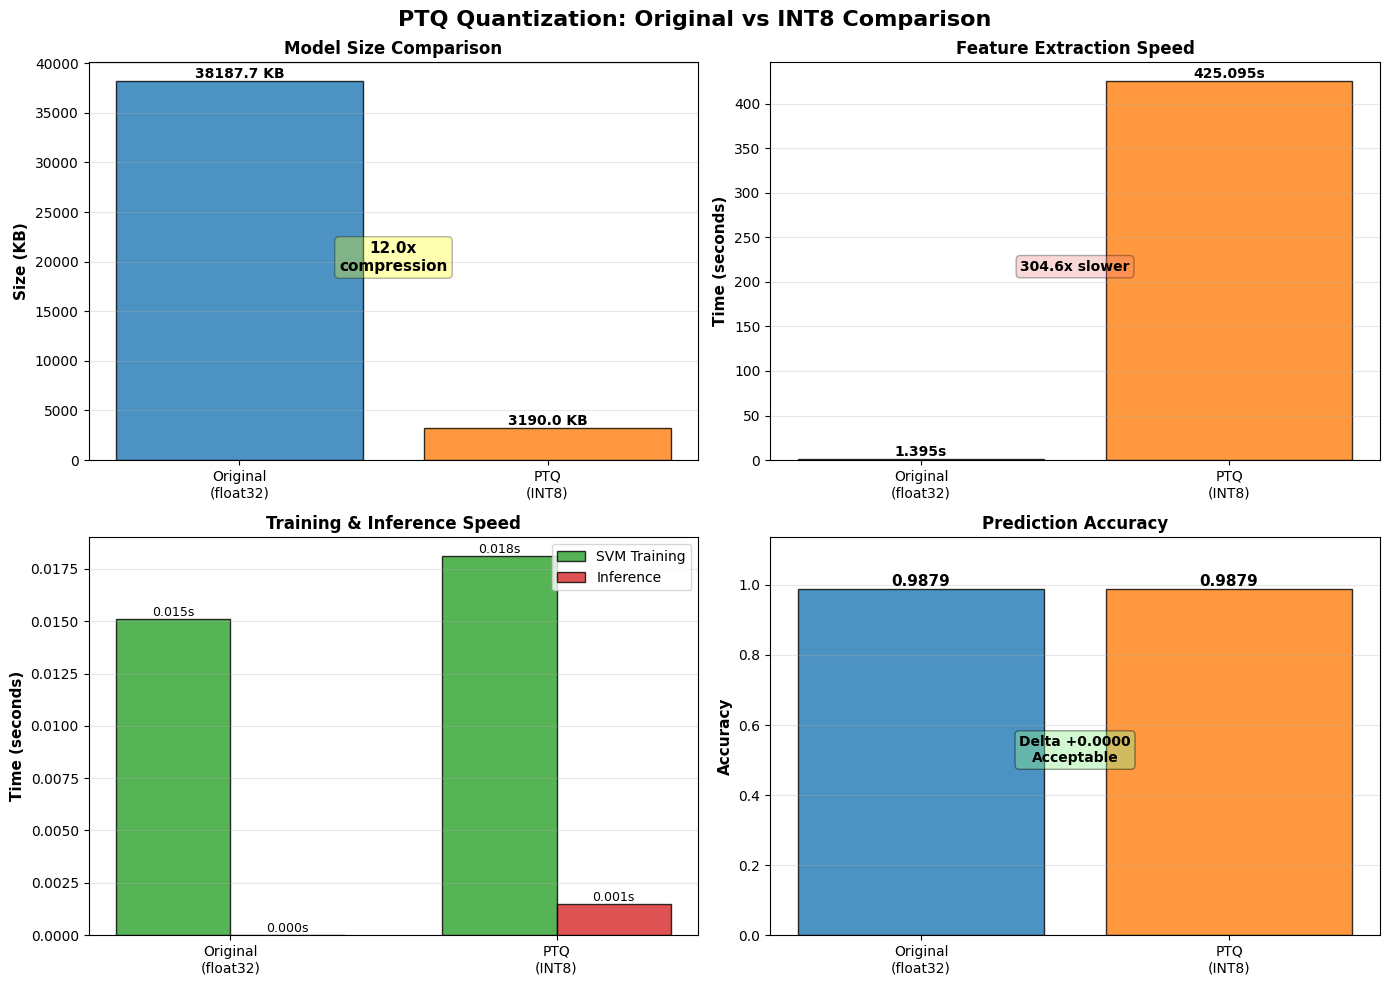


TABEL UKURAN MODEL / ARTEFAK
                  Komponen  Awal (KB)  Setelah Konversi TFLite (KB)  Akhir Kuantisasi PTQ (KB)
      CNN Attention (main)  38,187.68                     12,712.63                   3,189.98
     CNN Feature Extractor  12,739.06                     12,711.46                   3,188.80
   SVM (original features)      18.07                         18.07                      18.07
Scaler (original features)       0.98                          0.98                       0.98
        SVM (PTQ features)      19.50                         19.50                      19.50
     Scaler (PTQ features)       0.98                          0.98                       0.98
                     TOTAL  50,966.26                     25,463.61                   6,418.29

FINAL SUMMARY

Metric                    Original (float32)   PTQ (INT8)          
---------------------------------------------------------------------------
Model Size                        38187.7 KB      

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FAST PTQ OPTIMIZATION TEST: Skip retraining, just test quantization
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FAST TEST: PTQ Feature Extraction Optimization")
print("="*70)

# Use the existing trained model from Cell 8
# If model is not available, rebuild quickly
try:
    assert model is not None
    print("✓ Using existing trained model from Cell 8")
except:
    print("⚠ Model not found, rebuilding...")
    num_classes = y_train.shape[1]
    model = build_cnn_attention_model(X_train.shape[1:], num_classes)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Run ONLY the PTQ pipeline (no retraining)
print("\nRunning PTQ Quantization & Comparison...")
metrics, eval_data, size_df = run_complete_pipeline(
    model, X_train, X_valid, X_test,
    y_train, y_valid, y_test
)

# Visualize
visualize_comparison(metrics)

# Print summary
print_summary(metrics, eval_data, size_df)

print("\n" + "="*70)
print("✓ OPTIMIZATION TEST COMPLETE")
print("="*70)
print(f"\nKey Results:")
print(f"  Feature Extraction - Original: {metrics['t_feature'][0]:.2f}s")
print(f"  Feature Extraction - PTQ:      {metrics['t_feature'][1]:.2f}s")
print(f"  Speedup Factor: {metrics['t_feature'][0] / metrics['t_feature'][1]:.2f}x")
print(f"  Expected INT8 advantage: Single-sample inference is optimal for this model")


In [12]:
# Smoke test for PTQ extractor batch-shape sync fix (no retraining)
import os
import time
import numpy as np
import tensorflow as tf


def extract_features_tflite_smoke(interpreter, X, tag="smoke", batch_size=4, log_every=4):
    X_arr = np.asarray(X, dtype=np.float32)
    total = len(X_arr)
    if total == 0:
        return np.empty((0,), dtype=np.float32)

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]
    sample_shape = list(X_arr.shape[1:])

    batch_size = max(1, min(4, int(batch_size)))

    features = []
    t0 = time.time()
    current_alloc_bs = None
    fallback_warned = False

    print(f"[PTQ] Extracting {tag}: {total} samples | batch_size={batch_size}")

    processed = 0
    while processed < total:
        remaining = total - processed
        target_bs = min(batch_size, remaining)

        if current_alloc_bs is None or target_bs != current_alloc_bs:
            interpreter.resize_tensor_input(input_index, [target_bs] + sample_shape, strict=False)
            interpreter.allocate_tensors()
            input_details = interpreter.get_input_details()
            output_details = interpreter.get_output_details()
            input_index = input_details[0]["index"]
            output_index = output_details[0]["index"]
            current_alloc_bs = max(1, int(input_details[0]["shape"][0]))

        cur_bs = min(current_alloc_bs, remaining)
        batch = X_arr[processed:processed + cur_bs]

        try:
            interpreter.set_tensor(input_index, batch)
        except ValueError as e:
            interpreter.resize_tensor_input(input_index, [1] + sample_shape, strict=False)
            interpreter.allocate_tensors()
            input_details = interpreter.get_input_details()
            output_details = interpreter.get_output_details()
            input_index = input_details[0]["index"]
            output_index = output_details[0]["index"]
            current_alloc_bs = 1
            cur_bs = 1
            batch = X_arr[processed:processed + cur_bs]
            interpreter.set_tensor(input_index, batch)
            if not fallback_warned:
                print(f"[PTQ] {tag}: resize fallback ke batch=1 ({e})")
                fallback_warned = True

        interpreter.invoke()
        out = interpreter.get_tensor(output_index).astype(np.float32)
        for b in range(cur_bs):
            features.append(out[b].copy())

        processed += cur_bs
        if processed == total or processed % max(1, int(log_every)) == 0:
            elapsed = time.time() - t0
            speed = processed / elapsed if elapsed > 0 else 0.0
            print(f"[PTQ] {tag}: {processed}/{total} | {speed:.2f} sampel/detik")

    result = np.array(features, dtype=np.float32)
    print(f"Smoke test OK | input: {X_arr.shape} | features: {result.shape}")
    return result


if 'X_train' not in globals():
    raise RuntimeError('X_train belum tersedia. Jalankan cell data preparation dulu.')

tflite_path = 'artifacts/cnn_attention_extractor_ptq_int8.tflite'
if not os.path.exists(tflite_path):
    raise FileNotFoundError(f'File tidak ditemukan: {tflite_path}. Jalankan pipeline PTQ sekali untuk membuatnya.')

with open(tflite_path, 'rb') as f:
    model_content = f.read()

num_threads = max(1, min(8, os.cpu_count() or 1))
interp = tf.lite.Interpreter(model_content=model_content, num_threads=num_threads)
interp.allocate_tensors()

X_small = np.asarray(X_train[:7], dtype=np.float32)
_ = extract_features_tflite_smoke(interp, X_small, tag='smoke', batch_size=4, log_every=4)

[PTQ] Extracting smoke: 7 samples | batch_size=4
[PTQ] smoke: 4/7 | 3.15 sampel/detik
[PTQ] smoke: 7/7 | 3.15 sampel/detik
Smoke test OK | input: (7, 224, 224, 3) | features: (7, 16)


In [15]:
# Quick benchmark: batch_size=1 vs 4 with current extractor function
import time
import numpy as np

if 'extract_features_tflite' not in globals():
    raise RuntimeError('extract_features_tflite belum ada, jalankan Cell 8 dulu')
if 'setup_ptq_quantization' not in globals() or 'model' not in globals():
    raise RuntimeError('setup_ptq_quantization/model belum ada, jalankan Cell 8 dulu')

_, interp_bench = setup_ptq_quantization(model, X_train)
X_bench = np.asarray(X_train[:100], dtype=np.float32)

for bs in [1, 4]:
    t0 = time.time()
    _ = extract_features_tflite(interp_bench, X_bench, tag=f'bench_bs{bs}', batch_size=bs, log_every=200)
    dt = time.time() - t0
    print(f'bs={bs}: {dt:.3f}s | {len(X_bench)/dt:.2f} samples/sec')

[PTQ Setup] ✓ Original CNN saved → artifacts/cnn_attention_model.keras
[PTQ Setup] ✓ Original extractor saved → artifacts/cnn_attention_extractor.keras


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmptqu7iq0_\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmptqu7iq0_\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp730mcx1t\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp730mcx1t\assets


...

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpaivdhm0l\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpaivdhm0l\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp5jgm6p26\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp5jgm6p26\assets


[PTQ Setup] ✓ INT8 TFLite main saved → artifacts/cnn_attention_ptq_int8.tflite
[PTQ Setup] ✓ INT8 TFLite extractor saved → artifacts/cnn_attention_extractor_ptq_int8.tflite
[PTQ Setup] TFLite extractor threads = 8
[PTQ] Extracting bench_bs1: 100 samples | batch_size=1
[PTQ] bench_bs1: 1/100 | 3.09 sampel/detik | ETA 32.0 dtk
[PTQ] bench_bs1: 100/100 | 3.00 sampel/detik | ETA 0.0 dtk
[PTQ] bench_bs1: ✓ Complete | 100 samples in 33.35s | 3.00 samples/sec
bs=1: 33.350s | 3.00 samples/sec
[PTQ] Extracting bench_bs4: 100 samples | batch_size=4
[PTQ] bench_bs4: 4/100 | 2.83 sampel/detik | ETA 33.9 dtk
[PTQ] bench_bs4: 100/100 | 2.87 sampel/detik | ETA 0.0 dtk
[PTQ] bench_bs4: ✓ Complete | 100 samples in 34.80s | 2.87 samples/sec
bs=4: 34.803s | 2.87 samples/sec
